← [Conceptos clave](13-conceptos-clave.ipynb) · [Índice](00-indice.ipynb)

# 14 · Conexiones físicas del sistema

Toda la serie anterior trata de cómo Reci **decide**. Este documento trata de
cómo esa decisión se convierte en una compuerta que se abre.

> Para ensamblar, la referencia operativa es
> [`docs/CONEXIONES.md`](../CONEXIONES.md), pensada para imprimir y tener al
> lado. Aquí se explica **por qué** el sistema está conectado así.

---



## La cadena completa

```
   persona            ┌──────────────┐
   acerca un   ────→  │  ESP32-CAM   │  captura 3 fotos
   residuo            │  (OV2640)    │
                      └──────┬───────┘
                             │ WiFi
                      ┌──────▼───────┐
                      │  Next.js API │  autenticación del robot
                      └──────┬───────┘
                             │ HTTP interno
                      ┌──────▼───────────────┐
                      │ Servicio de visión   │  proveedor + experto + CNN
                      └──────┬───────────────┘
                             │ { material, confidence }
                      ┌──────▼───────┐
                      │  ESP32-CAM   │
                      └──────┬───────┘
                             │ Serial TX/RX  ── CMD:OPEN:vidrio
                      ┌──────▼──────────┐
                      │ Arduino Mega    │  controlador central
                      └──────┬──────────┘
                             │ PWM
                      ┌──────▼───────┐
                      │    Servo     │  abre la compuerta
                      └──────────────┘
```

Dos controladores con papeles distintos:

| | ESP32-CAM | Arduino Mega 2560 |
| --- | --- | --- |
| Papel | Ojos y red | Cuerpo y actuadores |
| Hace | Capturar, enviar por WiFi, recibir el veredicto | Motores, servos, sensores, pantalla |
| No hace | Mover nada | Hablar con Internet |

La división existe porque el Mega no tiene WiFi ni cámara, y el ESP32-CAM tiene
pocos pines libres. Cada uno hace lo que su hardware permite.

---



## Las tres reglas eléctricas que no se rompen

### 1. Todas las tierras van unidas

```
GND LiPo ── GND Mega ── GND L298N#1 ── GND L298N#2 ── GND ESP32 ── GND sensores
```

Un voltaje es siempre una **diferencia** entre dos puntos. Si dos módulos no
comparten referencia, "5 V" en uno no significa lo mismo que en el otro, y la
comunicación serial falla de forma intermitente — el peor tipo de fallo, porque
parece un problema de software.

### 2. El ESP32-CAM es de 3,3 V

Sus pines **no toleran 5 V**. El Arduino Mega transmite a 5 V, así que la línea
`TX1 del Mega → U0RXD del ESP32` necesita un **divisor de voltaje** que la baje
a ~3,3 V.

```
Mega TX1 (pin 18) ──[ R1 ]──┬──[ R2 ]── GND
                            │
                            └──→ ESP32 U0RXD  (~3,3 V)
```

La dirección contraria no lo necesita: el ESP32 transmite a 3,3 V y el Mega lo
lee como nivel alto sin problema. **El divisor es obligatorio y va en un solo
sentido.**

### 3. Los motores y la electrónica no comparten fuente

| Fuente | Alimenta |
| --- | --- |
| LiPo 7,4 V | Motores (L298N ×2) y el Mega por VIN |
| Power Bank 10 Ah | Electrónica sensible |
| LM2596 (7,4 V → 5,0 V) | ESP32-CAM |

Un motor al arrancar consume un pico de corriente que hunde el voltaje de la
línea. Si el ESP32 comparte esa línea, se reinicia justo cuando el robot empieza
a moverse. Por eso los motores van por su lado y el LM2596 entrega 5 V estables
—hay que ajustarlo con su potenciómetro **antes** de conectar el ESP32.

---



## Mapa de pines del Arduino Mega

| Pines | Componente | Función |
| --- | --- | --- |
| 2–7 | L298N #1 | Ruedas izquierdas (IN1-IN4 + ENA/ENB por PWM) |
| 8–13 | L298N #2 | Ruedas derechas |
| 16, 17 | HC-05 | Bluetooth (Serial2) |
| **18, 19** | **ESP32-CAM** | **Serial1 — 18 lleva el divisor de voltaje** |
| 20, 21 | Bus I2C | OLED + MPU HW-123 (SDA/SCL) |
| 22–27 | HC-SR04 ×3 | Ultrasonidos frontal, izquierdo, derecho (TRIG/ECHO) |
| 28 | PIR | Detector de presencia |
| **44, 45** | **Servos** | **44 = compuerta plástico · 45 = compuerta vidrio** |

Los dos que conectan con toda la serie anterior son **18/19** (por donde llega
el veredicto) y **44/45** (donde se ejecuta).

Dos detalles del diseño:

- **ENA/ENB deben ir en pines PWM.** Controlan la velocidad por ancho de pulso;
  en un pin digital normal los motores solo tendrían apagado y a fondo.
- **El bus I2C comparte dos pines entre varios dispositivos.** OLED y MPU
  conviven en 20/21 porque cada uno tiene su propia dirección.

---



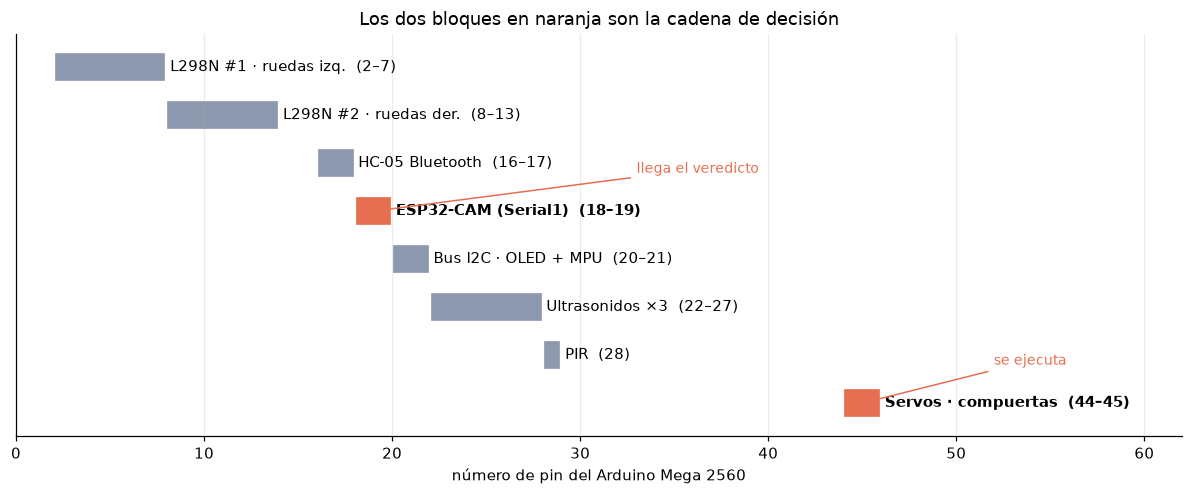

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

VIDRIO, PLASTICO, GRIS, ALERTA = "#2a9d8f", "#e9c46a", "#8d99ae", "#e76f51"
plt.rcParams.update({
    "figure.dpi": 110, "font.size": 10, "axes.grid": True,
    "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False,
})

# Reparto de los pines del Mega por subsistema
fig, ax = plt.subplots(figsize=(11, 4.6))

bloques = [
    ("L298N #1 · ruedas izq.",  2,  7, GRIS),
    ("L298N #2 · ruedas der.",  8, 13, GRIS),
    ("HC-05 Bluetooth",        16, 17, GRIS),
    ("ESP32-CAM (Serial1)",    18, 19, ALERTA),
    ("Bus I2C · OLED + MPU",   20, 21, GRIS),
    ("Ultrasonidos ×3",        22, 27, GRIS),
    ("PIR",                    28, 28, GRIS),
    ("Servos · compuertas",    44, 45, ALERTA),
]
for i, (nombre, ini, fin, color) in enumerate(bloques):
    ax.barh(i, fin - ini + 1, left=ini, height=0.62, color=color,
            edgecolor="white", lw=1.5)
    rango = f"{ini}" if ini == fin else f"{ini}–{fin}"
    ax.text(fin + 1.2, i, f"{nombre}  ({rango})", va="center", fontsize=9.5,
            weight="bold" if color == ALERTA else "normal")

ax.set_yticks([]); ax.set_xlabel("número de pin del Arduino Mega 2560")
ax.set(xlim=(0, 62), title="Los dos bloques en naranja son la cadena de decisión")
ax.invert_yaxis(); ax.grid(axis="x", alpha=0.25)
ax.annotate("llega el veredicto", xy=(19, 3), xytext=(33, 2.2),
            arrowprops=dict(arrowstyle="->", color=ALERTA), color=ALERTA, fontsize=9)
ax.annotate("se ejecuta", xy=(45, 7), xytext=(52, 6.2),
            arrowprops=dict(arrowstyle="->", color=ALERTA), color=ALERTA, fontsize=9)

plt.tight_layout(); plt.show()

## El ESP32-CAM

| Pin | Conexión |
| --- | --- |
| 5V | LM2596 OUT (5 V regulados) |
| GND | GND común |
| U0TXD | → RX1 del Mega (pin 19) — directo |
| U0RXD | ← TX1 del Mega (pin 18) — **con divisor** |
| IO0 | → GND **solo para programar**, quitar después |

`IO0` a GND pone el módulo en modo flash. Si se olvida conectado, el ESP32
arranca esperando firmware nuevo en vez de ejecutar el suyo — y parece
"muerto" sin estarlo.

Secuencia para programar: conectar el ESP32-CAM-MB, `IO0 → GND`, USB al PC,
cargar, **desconectar IO0**, RESET.

---



## El protocolo entre los dos controladores

Una sola línea de texto por el puerto serial:

```
CMD:OPEN:vidrio
CMD:OPEN:plastico
```

Cuando el material es `desconocido`, **no se envía nada**. La ausencia de
comando es la abstención del documento [10](10-votacion-y-decision.ipynb)
expresada en hardware: si el sistema no está seguro, ningún servo se mueve.

Es la traducción física del principio que atraviesa el proyecto: abrir la
compuerta equivocada contamina un contenedor entero; no abrir ninguna solo
molesta a una persona.

---



## Orden de ensamble

Nunca todo a la vez. Cada etapa se prueba antes de la siguiente:

```
1. Energía y tierra común        5. Sensores (ultrasonidos + PIR)
2. Arduino Mega solo             6. OLED + MPU (I2C)
3. Motores + L298N               7. ESP32-CAM
4. Servomotores                  8. Prueba integrada
```

La razón es diagnóstica: si se conecta todo y algo falla, hay decenas de
causas posibles. Añadiendo una etapa a la vez, el culpable es siempre lo último
que se tocó.

---



## Dónde encaja el modelo

Vale la pena cerrar la serie situando las 18.030 imágenes, las 193 reglas y las
nueve corridas de entrenamiento:

```
todo eso  →  produce  →  una cadena de texto de 16 caracteres
                          CMD:OPEN:vidrio
                             ↓
                          un servo gira ~90°
```

Ese es el producto final. Y explica por qué el proyecto prefiere abstenerse:
el resto del sistema —red, servicio, votación— puede reintentar, pero un servo
que se movió ya movió.

---

← [Conceptos clave](13-conceptos-clave.ipynb) · [Índice](00-indice.ipynb)
